## Logistic Regression


1. Why we need to move from linear to logistic
2. Why it is called logistic regression
3. Math behind Logistic regression
4. sigmoid function with calculation
5. Understanding m & c values
6. Confusion matrix
7. Evaluation metrics
8. End-to-end logisitc regression
9. Real time examples


1. Why we need to move from linear to logistic       
Linear Regression predicts continous values      
 Examples:      
 House price prediction     
 salaray          
 Marks predictions          
But what if we want:         
pass/fail         
Spam / Not Spam           
Disease / No Disease           
Above are the classfication problems    
Linear regression may predict       
1.8       
-2.5        
0.8       
which does not make sense for classification so we need output between 0&1 this is the reason behind the usage of logistic regression.

2. Why it is called logistic regression     
Logistic regression uses a regression equation internally:z=mx + c       
Then it applies a special function called sigmoid function:z=1/(1+e^(-z))    
This converts values from:-infinity to +infinity       
into:0 to 1   
Hence it performs classification using regression mathematics.

3. Math behind Logistic regression    
Equation: z=mx+c   
m=slope   
c=intercept    
x=input variable    
Example:  
m=2   
c=-6  
z=2x - 6    
code:   
x=4    
z=(m*x) + c     
print("m value:",m)     
print("c value:",c)       
print("x value:",x)         
print("z value:",z)            



4. sigmoid function with calculation     
import math     
z=2    
sigmoid = 1/(1+math.exp(-z))     
print("z value:",z)    
print("sigmoid Probability:",sigmoid)       
if probability > 0.5 :    
 class = 1     
 else:      
 class = 0    
 probability = sigmoid     
 if probability > 0.5:                
      print("Prediction : Pass (Class 1)")     
else:    
     print("Predicition : Fail (Class 0)")

In [15]:
#mathematical equation for logistic regression
#z = mx + c
m = 2
c = -6
x = 4
z = (m * x) + c
print("m value:", m)
print("c value:", c)
print("x value:", x)
print("z value:", z)

m value: 2
c value: -6
x value: 4
z value: 2


In [16]:
#sigmoid function calculation
import math

z = 2

probability = 1 / (1 + math.exp(-z))

print("z value:", z)
print("Sigmoid probability:", probability)

if probability >= 0.5:
    print("Class: Pass (Class 1)")
else:
    print("Class: Fail (Class 0)")

z value: 2
Sigmoid probability: 0.8807970779778823
Class: Pass (Class 1)


Visualizing the sigmoid curve

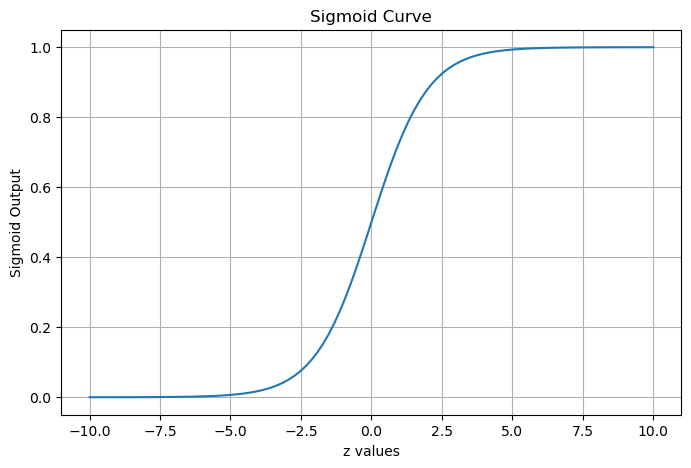

In [17]:
import matplotlib.pyplot as plt
import numpy as np
x=np.linspace(-10, 10, 100)
y=1/(1+np.exp(-x))
plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("z values")
plt.ylabel("Sigmoid Output")
plt.title('Sigmoid Curve')
plt.grid(True)
plt.show()

Confusion Matrix     


In [18]:
#actual      Predicted        Result
#1           1              True Positive       
#1         0              False Negative       
#0           1               False Positive       
#0           0               True Negative

Evaluation Metrics:       
1. Accuracy     
Accuracy = TP + TN/TP+TN+FP+FN      

2. Precision    
Precision = TP/TP+FP

3. Recall   
Recall = TP/TP+FN

4. F1 Score   
F1 = 2* Precision * Recall / Precision + Recall

Logisitc Regression End to End  
#Student Pass or fail Prediction:   
Study Hours   
target:    
Pass or fail


In [19]:
#import Libraries
import pandas as pd
import numpy as np
#create a dataset
data = {
    "Study Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Pass / Fail": [0, 0, 0, 0,1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)
print(df)


   Study Hours  Pass / Fail
0            1            0
1            2            0
2            3            0
3            4            0
4            5            1
5            6            1
6            7            1
7            8            1
8            9            1
9           10            1


Separate Dependent and Independent Variables

In [20]:
x=df['Study Hours']
y=df['Pass / Fail']
print(x)
print(y)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Study Hours, dtype: int64
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    1
9    1
Name: Pass / Fail, dtype: int64


Tarin Test Split

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training data size:", len(x_train))
print("Testing data size:", len(x_test))

Training data size: 8
Testing data size: 2


Train the logistic regression Model

In [24]:
#training the logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train.values.reshape(-1, 1), y_train)
y_pred = model.predict(x_test.values.reshape(-1, 1))
print("Predicted values:", y_pred)
print("Actual values:", y_test.values)

Predicted values: [1 0]
Actual values: [1 0]


m & c values

In [29]:
m=model.coef_[0][0]
c=model.intercept_[0]
print("m value:", m)
print("c value:", c)
x=5
z=m*x+c
print("For x = ",x)
print("Calucualted z value:", z)
probability = 1 / (1 + math.exp(-z))
print("Sigmoid probability:", probability)
if probability >0.6:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

m value: 1.1188238520249385
c value: -4.961982702816975
For x =  5
Calucualted z value: 0.6321365573077173
Sigmoid probability: 0.65297376210517
Prediction: Pass
Confusion Matrix:
[[1 0]
 [0 1]]


Accuracy

In [30]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Precision, Recall and F1 Score

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0
